# 🔍 Agent Pipeline Evaluation Dashboard

Loads all `*_node_activity.json` files from `output/results/` and produces clean, scalable visualisations that stay readable regardless of how many log files are present.

---

In [29]:
import json, re, glob, warnings
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
})

NODE_COLORS = {
    "match_schemas":        "#2ecc71",
    "profile_data":         "#27ae60",
    "run_blocking_tester":  "#1abc9c",
    "run_matching_tester":  "#16a085",
    "pipeline_adaption":    "#f39c12",
    "execute_pipeline":     "#3498db",
    "evaluation_adaption":  "#e67e22",
    "execute_evaluation":   "#2980b9",
    "evaluation_decision":  "#9b59b6",
    "evaluation_reasoning": "#8e44ad",
}
DEFAULT_COLOR = "#95a5a6"

NODE_ORDER = [
    "match_schemas", "profile_data", "run_blocking_tester", "run_matching_tester",
    "pipeline_adaption", "execute_pipeline",
    "evaluation_adaption", "execute_evaluation",
    "evaluation_decision", "evaluation_reasoning",
]

print("OK  imports & style loaded.")


OK  imports & style loaded.


---
## 1 · Data Loading

In [30]:
LOG_DIR   = Path("output/results")
log_files = sorted(glob.glob(str(LOG_DIR / "**" / "*_node_activity.json"), recursive=True))

if not log_files:
    raise FileNotFoundError(f"No *_node_activity.json files found under '{LOG_DIR}'.")

# ── Helpers ────────────────────────────────────────────────────────────────────
def parse_accuracy(s):
    m = re.search(r"([\d.]+)%", str(s or ""))
    return float(m.group(1)) if m else None

def short_label(run_id, max_len=38):
    s = run_id.replace("_node_activity", "")
    s = re.sub(r"_\d{6}_\d+$", "", s)
    if len(s) > max_len:
        s = s[:14] + "..." + s[-(max_len - 17):]
    return s

def infer_run_id(filepath):
    return Path(filepath).stem.replace("_node_activity", "")

def load_notebook_name(node_activity_path):
    """Read notebook_name from the sibling _pipelines.md file."""
    p = Path(node_activity_path)
    pipelines_path = p.parent / p.name.replace("_node_activity.json", "_pipelines.md")
    if pipelines_path.exists():
        with open(pipelines_path, "r", encoding="utf-8") as fh:
            for line in fh:
                if line.startswith("notebook_name="):
                    return line.split("=", 1)[1].strip()
    return None

def infer_pipeline_type(notebook_name, run_id):
    """Extract pipeline type from notebook_name by stripping common prefix."""
    s = notebook_name or run_id
    s = re.sub(r"^AdaptationPipeline_[^_]+_[^_]+_[^_]+_Final_?", "", s)
    s = re.sub(r"_\d{6}_\d+$", "", s)
    return s.strip("_") or s

def load_run(filepath):
    with open(filepath, "r", encoding="utf-8") as fh:
        data = json.load(fh)
    run_id  = infer_run_id(filepath)
    label   = short_label(run_id)
    nb_name = load_notebook_name(filepath)
    pt      = infer_pipeline_type(nb_name, run_id)
    use_case = data.get("use_case") or data.get("usecase") or data.get("use-case") or "unknown"

    nodes = []
    for n in data.get("node_activity", []):
        nodes.append({
            "run_id":             run_id,
            "label":              label,
            "use_case":           use_case,
            "pipeline_type":      pt,
            "current_node":       n.get("current_node"),
            "next_node":          n.get("next_node"),
            "prompt_tokens":      n.get("prompt_tokens", 0),
            "completion_tokens":  n.get("completion_tokens", 0),
            "total_tokens":       n.get("total_tokens", 0),
            "estimated_cost_usd": n.get("estimated_cost_usd", 0.0),
            "duration_seconds":   n.get("duration_seconds", 0.0),
            "status":             n.get("status", "unknown"),
            "error":              n.get("error"),
            "output_summary":     " | ".join(n.get("output_summary") or []),
        })

    eval_runs = []
    for i, ev in enumerate(data.get("evaluation_runs", []), 1):
        eval_runs.append({
            "run_id":           run_id,
            "label":            label,
            "use_case":         use_case,
            "pipeline_type":    pt,
            "eval_iteration":   i,
            "accuracy_pct":     parse_accuracy(ev.get("accuracy_score")),
            "attribute_fusers": ev.get("attribute_fusers", {}),
            "eval_functions":   ev.get("evaluation_functions", {}),
        })

    blocking_rows = []
    bc = (data.get("run_configs") or {}).get("blocking_config", {})
    for pair, v in bc.get("blocking_strategies", {}).items():
        blocking_rows.append({
            "run_id":            run_id,
            "label":             label,
            "use_case":          use_case,
            "pipeline_type":     pt,
            "pair":              pair,
            "strategy":          v.get("strategy"),
            "columns":           ", ".join(v.get("columns", [])),
            "pair_completeness": v.get("pair_completeness"),
            "num_candidates":    v.get("num_candidates"),
            "is_acceptable":     v.get("is_acceptable"),
            "params":            json.dumps(v.get("params", {})),
        })

    matching_rows = []
    mc = (data.get("run_configs") or {}).get("matching_config", {})
    for pair, v in mc.get("matching_strategies", {}).items():
        matching_rows.append({
            "run_id":        run_id,
            "label":         label,
            "use_case":      use_case,
            "pipeline_type": pt,
            "pair":          pair,
            "threshold":     v.get("threshold"),
            "f1":            v.get("f1"),
            "n_comparators": len(v.get("comparators", [])),
            "weights":       json.dumps(v.get("weights", [])),
            "comparators":   json.dumps([
                {"col": c.get("column"), "type": c.get("type"),
                 "fn":  c.get("similarity_function")}
                for c in v.get("comparators", [])
            ]),
        })

    tc = data.get("time_complexity", {})
    ts = data.get("transition_stats", {})

    return {
        "run_id":          run_id,
        "label":           label,
        "notebook_name":   nb_name,
        "pipeline_type":   pt,
        "use_case":        use_case,
        "nodes":           pd.DataFrame(nodes),
        "eval_runs":       eval_runs,
        "blocking":        pd.DataFrame(blocking_rows),
        "matching":        pd.DataFrame(matching_rows),
        "time_summary": {
            "total_duration_s":    tc.get("total_duration_seconds", 0),
            "per_node_cumulative": tc.get("per_node_cumulative_durations_seconds", {}),
        },
        "transition_summary": {
            "total_nodes_logged": ts.get("total_nodes_logged", 0),
            "transition_counts":  ts.get("transition_counts", {}),
        },
        "raw": data,
    }


# ── Load ───────────────────────────────────────────────────────────────────────
runs, load_errors = {}, []
for fp in log_files:
    try:
        r = load_run(fp)
        runs[r["run_id"]] = r
    except Exception as e:
        load_errors.append((fp, str(e)))

all_nodes    = pd.concat([v["nodes"]    for v in runs.values()], ignore_index=True)
all_blocking = pd.concat([v["blocking"] for v in runs.values()], ignore_index=True)
all_matching = pd.concat([v["matching"] for v in runs.values()], ignore_index=True)
all_eval     = pd.DataFrame([row for v in runs.values() for row in v["eval_runs"]])

# Colour maps
run_ids    = list(runs.keys())
cmap_runs  = plt.cm.get_cmap("tab20", max(len(run_ids), 1))
RUN_COLOR  = {rid: cmap_runs(i) for i, rid in enumerate(run_ids)}
RUN_LABEL  = {rid: r["label"] for rid, r in runs.items()}

pipeline_types = sorted(all_eval["pipeline_type"].dropna().unique()) if not all_eval.empty else []
use_cases      = sorted(all_eval["use_case"].dropna().unique())      if not all_eval.empty else []
cmap_pt    = plt.cm.get_cmap("tab10", max(len(pipeline_types), 1))
PT_COLOR   = {pt: cmap_pt(i) for i, pt in enumerate(pipeline_types)}
cmap_uc    = plt.cm.get_cmap("Set2",  max(len(use_cases), 1))
UC_COLOR   = {uc: cmap_uc(i) for i, uc in enumerate(use_cases)}

# ── Summary box ────────────────────────────────────────────────────────────────
W = 58
print("\u2554" + "\u2550"*W + "\u2557")
print("\u2551" + " Pipeline Evaluation \u2014 Load Summary".center(W) + "\u2551")
print("\u2560" + "\u2550"*W + "\u2563")
for lbl, val in [
    ("Runs loaded",        len(runs)),
    ("Use cases",          len(use_cases)),
    ("Pipeline types",     len(pipeline_types)),
    ("Total node records", len(all_nodes)),
    ("Eval iterations",    len(all_eval)),
    ("Blocking configs",   len(all_blocking)),
    ("Matching configs",   len(all_matching)),
]:
    print(f"\u2551  {lbl:<28}: {str(val):<{W-33}} \u2551")
if load_errors:
    print(f"\u2551  {'Load errors':<28}: {str(len(load_errors)):<{W-33}} \u2551")
print("\u255a" + "\u2550"*W + "\u255d")

print("\nLoaded runs:")
for rid, r in runs.items():
    print(f"  OK  {r['label']:<40}  [{r['pipeline_type']}]  use_case={r['use_case']}  ({len(r['nodes'])} nodes, {len(r['eval_runs'])} eval iters)")
if load_errors:
    print("\nFailed:")
    for fp, err in load_errors:
        print(f"  ERR  {Path(fp).name}: {err}")

if pipeline_types:
    print("\nPipeline types:")
    for pt in pipeline_types:
        n = sum(1 for r in runs.values() if r["pipeline_type"] == pt)
        print(f"  {pt:<40} {n} run(s)")

if use_cases:
    print("\nUse cases:")
    for uc in use_cases:
        n = sum(1 for r in runs.values() if r["use_case"] == uc)
        print(f"  {uc:<40} {n} run(s)")


╔══════════════════════════════════════════════════════════╗
║            Pipeline Evaluation — Load Summary            ║
╠══════════════════════════════════════════════════════════╣
║  Runs loaded                 : 16                        ║
║  Use cases                   : 4                         ║
║  Pipeline types              : 3                         ║
║  Total node records          : 344                       ║
║  Eval iterations             : 48                        ║
║  Blocking configs            : 36                        ║
║  Matching configs            : 36                        ║
╚══════════════════════════════════════════════════════════╝

Loaded runs:
  OK  AdaptationPipe...er_Matcher_rule_based    [Blocker_Matcher]  use_case=Music  (25 nodes, 3 eval iters)
  OK  AdaptationPipe...er_Matcher_rule_based    [Blocker_Matcher]  use_case=Restaurants  (19 nodes, 3 eval iters)
  OK  AdaptationPipe...er_Matcher_rule_based    [Blocker_Matcher]  use_case=Games  (21 nodes,

---
## 2 · Run Overview

In [31]:
overview_rows = []
for run_id, r in runs.items():
    nodes      = r["nodes"]
    evals      = r["eval_runs"]
    ts         = r["time_summary"]
    tr         = r["transition_summary"]
    accuracies = [e["accuracy_pct"] for e in evals if e["accuracy_pct"] is not None]
    exc_count  = int(nodes["next_node"].str.contains("EXCEPTION", na=False).sum())

    overview_rows.append({
        "Use Case":          r["use_case"],
        "Pipeline Type":     r["pipeline_type"],
        "Run":               r["label"],
        "Duration (min)":    round(ts["total_duration_s"] / 60, 1),
        "Nodes logged":      tr["total_nodes_logged"],
        "Eval iterations":   len(evals),
        "Initial acc. (%)":  accuracies[0]  if accuracies else None,
        "Final acc. (%)":    accuracies[-1] if accuracies else None,
        "Gain (pp)":         round(accuracies[-1] - accuracies[0], 2) if len(accuracies) > 1 else 0.0,
        "Exceptions":        exc_count,
        "LLM tokens":        int(nodes["total_tokens"].sum()),
    })

overview_df = pd.DataFrame(overview_rows).sort_values(["Use Case", "Pipeline Type", "Final acc. (%)"], ascending=[True, True, False])

display(
    overview_df.style
    .background_gradient(subset=["Final acc. (%)"],  cmap="YlGn",   vmin=40, vmax=100)
    .background_gradient(subset=["Gain (pp)"],        cmap="Blues",  vmin=0)
    .background_gradient(subset=["Exceptions"],       cmap="Reds",   vmin=0, vmax=5)
    .background_gradient(subset=["Duration (min)"],   cmap="Purples")
    .format({
        "Initial acc. (%)": "{:.2f}",
        "Final acc. (%)":   "{:.2f}",
        "Gain (pp)":        "{:+.2f}",
        "LLM tokens":       "{:,}",
    }, na_rep="\u2014")
    .set_caption("Pipeline Run Overview")
    .hide(axis="index")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"),("font-weight","bold")]}])
)


Use Case,Pipeline Type,Run,Duration (min),Nodes logged,Eval iterations,Initial acc. (%),Final acc. (%),Gain (pp),Exceptions,LLM tokens
Books,AdaptationPipeline,AdaptationPipeline_rule_based,10.700000,16,3,59.29,53.57,-5.72,0,"46,202"
Books,Blocker_Matcher,AdaptationPipe...er_Matcher_rule_based,37.700000,23,3,69.29,60.00,-9.29,0,"97,754"
Books,Reasoning,AdaptationPipe...on_Final_Reasoning_ml,35.200000,23,3,57.14,65.00,+7.86,0,"138,813"
Books,Reasoning,AdaptationPipe..._Reasoning_rule_based,20.800000,21,3,62.14,59.29,-2.85,0,"93,489"
Games,AdaptationPipeline,AdaptationPipeline_rule_based,6.400000,16,3,61.34,59.66,-1.68,0,"48,308"
Games,Blocker_Matcher,AdaptationPipe...er_Matcher_rule_based,95.000000,21,3,29.41,73.95,+44.54,0,"60,128"
Games,Reasoning,AdaptationPipe...on_Final_Reasoning_ml,79.000000,23,3,78.99,84.87,+5.88,0,"128,303"
Games,Reasoning,AdaptationPipe..._Reasoning_rule_based,73.000000,23,3,29.41,84.87,+55.46,0,"117,643"
Music,AdaptationPipeline,AdaptationPipeline_rule_based,6.500000,18,3,36.04,26.90,-9.14,0,"57,852"
Music,Blocker_Matcher,AdaptationPipe...er_Matcher_rule_based,19.600000,25,3,50.76,51.27,+0.51,0,"100,331"


---
## 3 · Accuracy Progression

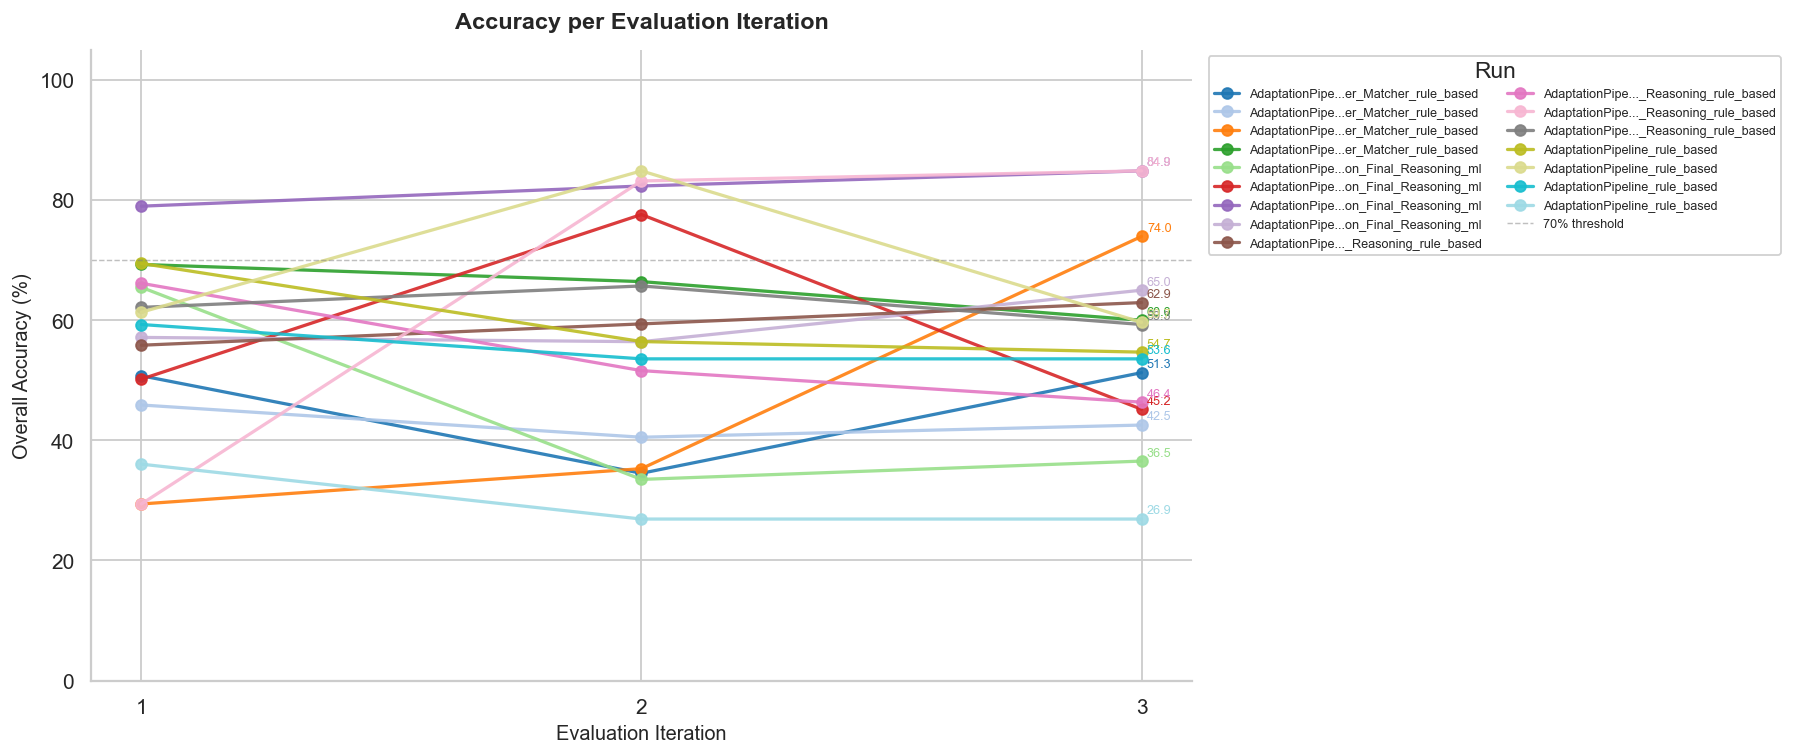

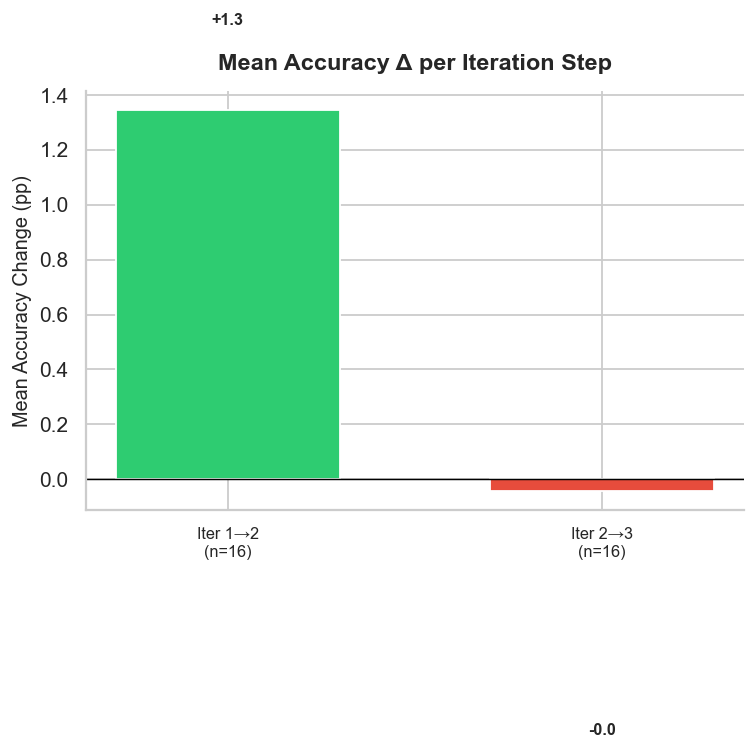

In [52]:
if all_eval.empty or all_eval["accuracy_pct"].isna().all():
    print("No accuracy data available.")
else:
    n_runs   = all_eval["run_id"].nunique()
    leg_ncol = max(1, n_runs // 10 + 1)

    # ── Plot 1: Accuracy per evaluation iteration (one line per run) ──────────
    fig, ax = plt.subplots(figsize=(14, 6))
    for run_id, grp in all_eval.groupby("run_id"):
        grp_s = grp.sort_values("eval_iteration")
        color = RUN_COLOR[run_id]
        ax.plot(grp_s["eval_iteration"], grp_s["accuracy_pct"],
                marker="o", linewidth=1.8, color=color,
                label=RUN_LABEL[run_id], alpha=0.9)
        last = grp_s.iloc[-1]
        ax.annotate(f"{last['accuracy_pct']:.1f}",
                    xy=(last["eval_iteration"], last["accuracy_pct"]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=7, color=color)
    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, alpha=0.5,
               label="70% threshold")
    ax.set_title("Accuracy per Evaluation Iteration", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Evaluation Iteration")
    ax.set_ylabel("Overall Accuracy (%)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylim(0, 105)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Run", fontsize=7, ncol=leg_ncol,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Mean accuracy delta per iteration step ────────────────────────
    delta_rows = []
    for run_id, grp in all_eval.groupby("run_id"):
        grp_s = grp.sort_values("eval_iteration").reset_index(drop=True)
        for j in range(1, len(grp_s)):
            p, c = grp_s.loc[j-1, "accuracy_pct"], grp_s.loc[j, "accuracy_pct"]
            if p is not None and c is not None:
                delta_rows.append({"step": f"Iter {j}\u2192{j+1}", "delta": c - p})

    if delta_rows:
        mean_delta = (pd.DataFrame(delta_rows)
                        .groupby("step", sort=False)["delta"]
                        .agg(mean_delta="mean", n="count")
                        .reset_index()
                        .sort_values("step"))

        fig, ax2 = plt.subplots(figsize=(max(6, len(mean_delta) * 1.4), 8))
        colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in mean_delta["mean_delta"]]
        bars   = ax2.bar(range(len(mean_delta)), mean_delta["mean_delta"],
                         color=colors, edgecolor="white", width=0.6)
        ax2.set_xticks(range(len(mean_delta)))
        ax2.set_xticklabels(
            [f"{r['step']}\n(n={r['n']})" for _, r in mean_delta.iterrows()],
            fontsize=9)
        ax2.axhline(0, color="black", linewidth=0.8)
        ax2.set_title("Mean Accuracy \u0394 per Iteration Step",
                      fontsize=13, fontweight="bold", pad=12)
        ax2.set_ylabel("Mean Accuracy Change (pp)")
        ax2.spines[["top", "right"]].set_visible(False)
        for bar, val in zip(bars, mean_delta["mean_delta"]):
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     val + (0.3 if val >= 0 else -0.9),
                     f"{val:+.1f}", ha="center", va="bottom", fontsize=9,
                     fontweight="bold")
        plt.tight_layout()
        plt.show()


---
## 4 · Node Activity Analysis

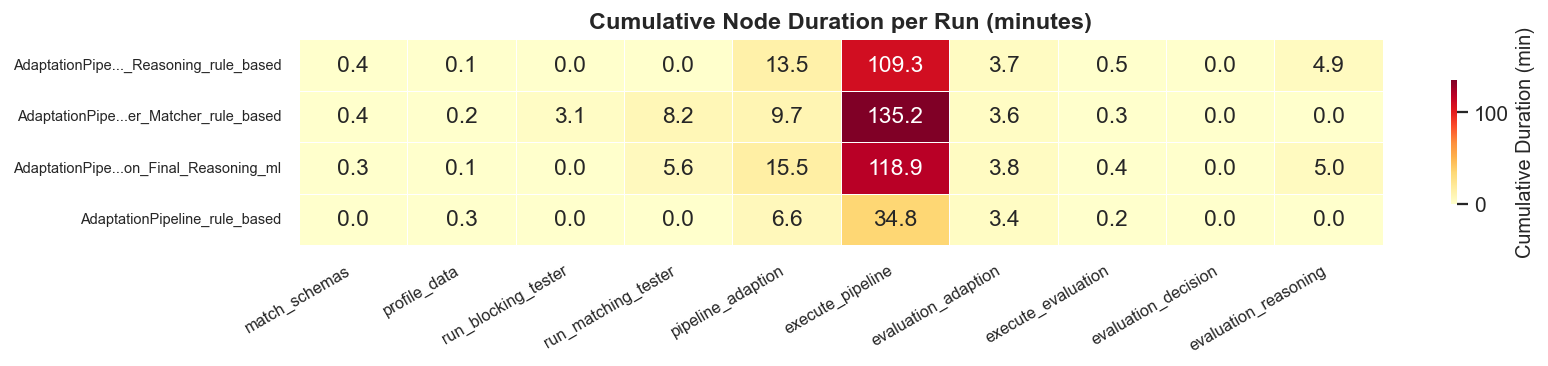

In [53]:
# ── 4a: Cumulative node duration heatmap (run x node) ─────────────────────────
tc_rows = []
for run_id, r in runs.items():
    per_node = r["time_summary"]["per_node_cumulative"]
    if not per_node:
        # Fallback: sum duration_seconds from raw node records
        per_node = (
            r["nodes"]
            .groupby("current_node")["duration_seconds"]
            .sum()
            .to_dict()
        )
    for node, dur in per_node.items():
        tc_rows.append({"label": r["label"], "node": node, "dur_s": dur})

tc_df = pd.DataFrame(tc_rows)

if not tc_df.empty:
    pivot = (tc_df.pivot_table(index="label", columns="node",
                               values="dur_s", aggfunc="sum")
                  .fillna(0))
    cols  = ([c for c in NODE_ORDER if c in pivot.columns] +
             [c for c in pivot.columns if c not in NODE_ORDER])
    pivot = pivot[cols]

    fig, ax = plt.subplots(figsize=(max(10, len(cols)*1.3),
                                    max(3, len(pivot)*0.55)))
    sns.heatmap(pivot / 60, annot=True, fmt=".1f", cmap="YlOrRd",
                linewidths=0.4, linecolor="white", ax=ax,
                cbar_kws={"label": "Cumulative Duration (min)", "shrink": 0.6})
    ax.set_title("Cumulative Node Duration per Run (minutes)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No time complexity data.")


C:\Users\Gregor Debus\AppData\Local\Temp\ipykernel_20504\440459147.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


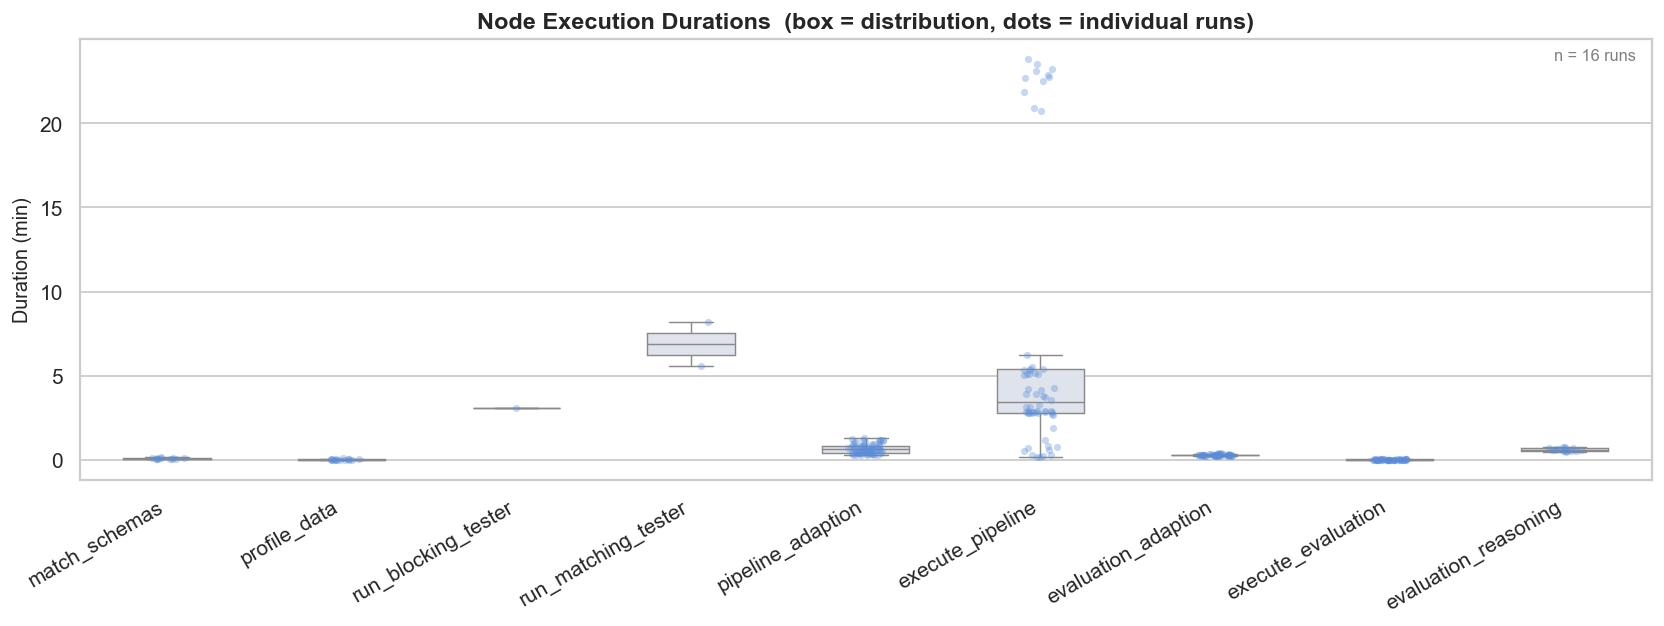

In [54]:
# ── 4b: Node duration distribution ────────────────────────────────────────────
# Box-plot always shown (summarises distribution across all runs).
# Strip overlay with per-run colours only when <= 8 runs (stays readable).
visible = all_nodes[all_nodes["duration_seconds"] > 0.1].copy()
visible["duration_min"] = visible["duration_seconds"] / 60
order   = ([n for n in NODE_ORDER if n in visible["current_node"].unique()] +
           [n for n in visible["current_node"].unique() if n not in NODE_ORDER])
n_runs  = all_nodes["run_id"].nunique()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=visible, x="current_node", y="duration_min",
            order=order, color="#dde3ee", width=0.5,
            fliersize=0, linewidth=0.8, ax=ax)

if n_runs <= 8:
    palette = {rid: RUN_COLOR[rid] for rid in all_nodes["run_id"].unique()}
    sns.stripplot(data=visible, x="current_node", y="duration_min",
                  hue="run_id", palette=palette,
                  order=order, jitter=True, size=5, alpha=0.8, ax=ax)
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, [RUN_LABEL[r] for r in all_nodes["run_id"].unique()],
              title="Run", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
else:
    # Many runs: neutral strip, count annotation
    sns.stripplot(data=visible, x="current_node", y="duration_min",
                  order=order, jitter=True, size=4, alpha=0.35,
                  color="#5b8dd9", ax=ax)
    ax.text(0.99, 0.98, f"n = {n_runs} runs",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="gray")

ax.set_title("Node Execution Durations  (box = distribution, dots = individual runs)",
             fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Duration (min)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

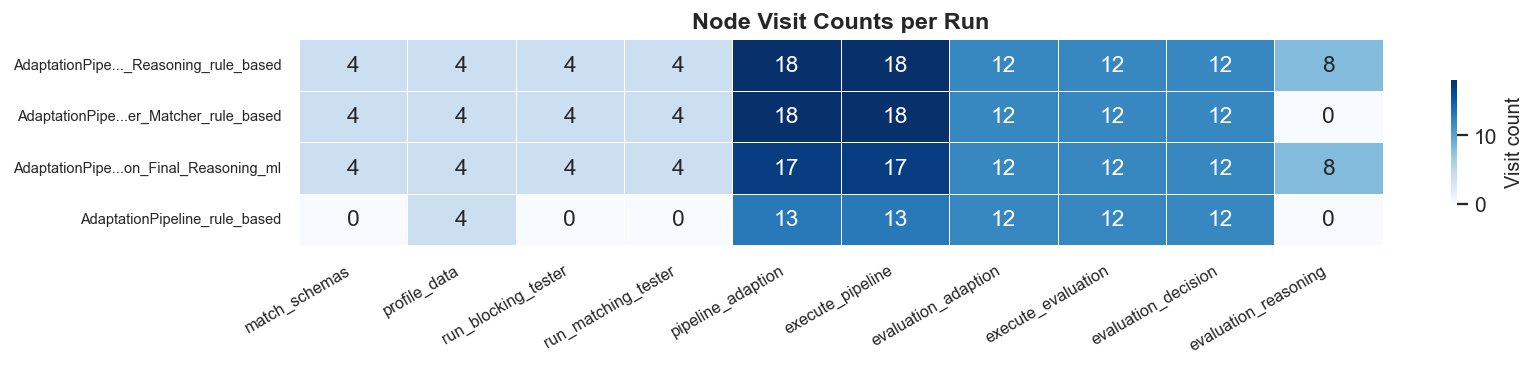

In [55]:
# ── 4c: Node visit counts heatmap (scales to any number of runs) ──────────────
pivot_v = (all_nodes.groupby(["label", "current_node"])
                    .size().reset_index(name="visits")
                    .pivot_table(index="label", columns="current_node",
                                 values="visits", aggfunc="sum")
                    .fillna(0))
cols_v  = ([c for c in NODE_ORDER if c in pivot_v.columns] +
           [c for c in pivot_v.columns if c not in NODE_ORDER])
pivot_v = pivot_v[cols_v]

fig, ax = plt.subplots(figsize=(max(10, len(cols_v)*1.3),
                                max(3, len(pivot_v)*0.55)))
sns.heatmap(pivot_v, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.4, linecolor="white", ax=ax,
            cbar_kws={"label": "Visit count", "shrink": 0.6})
ax.set_title("Node Visit Counts per Run", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5 · Token & Cost Analysis

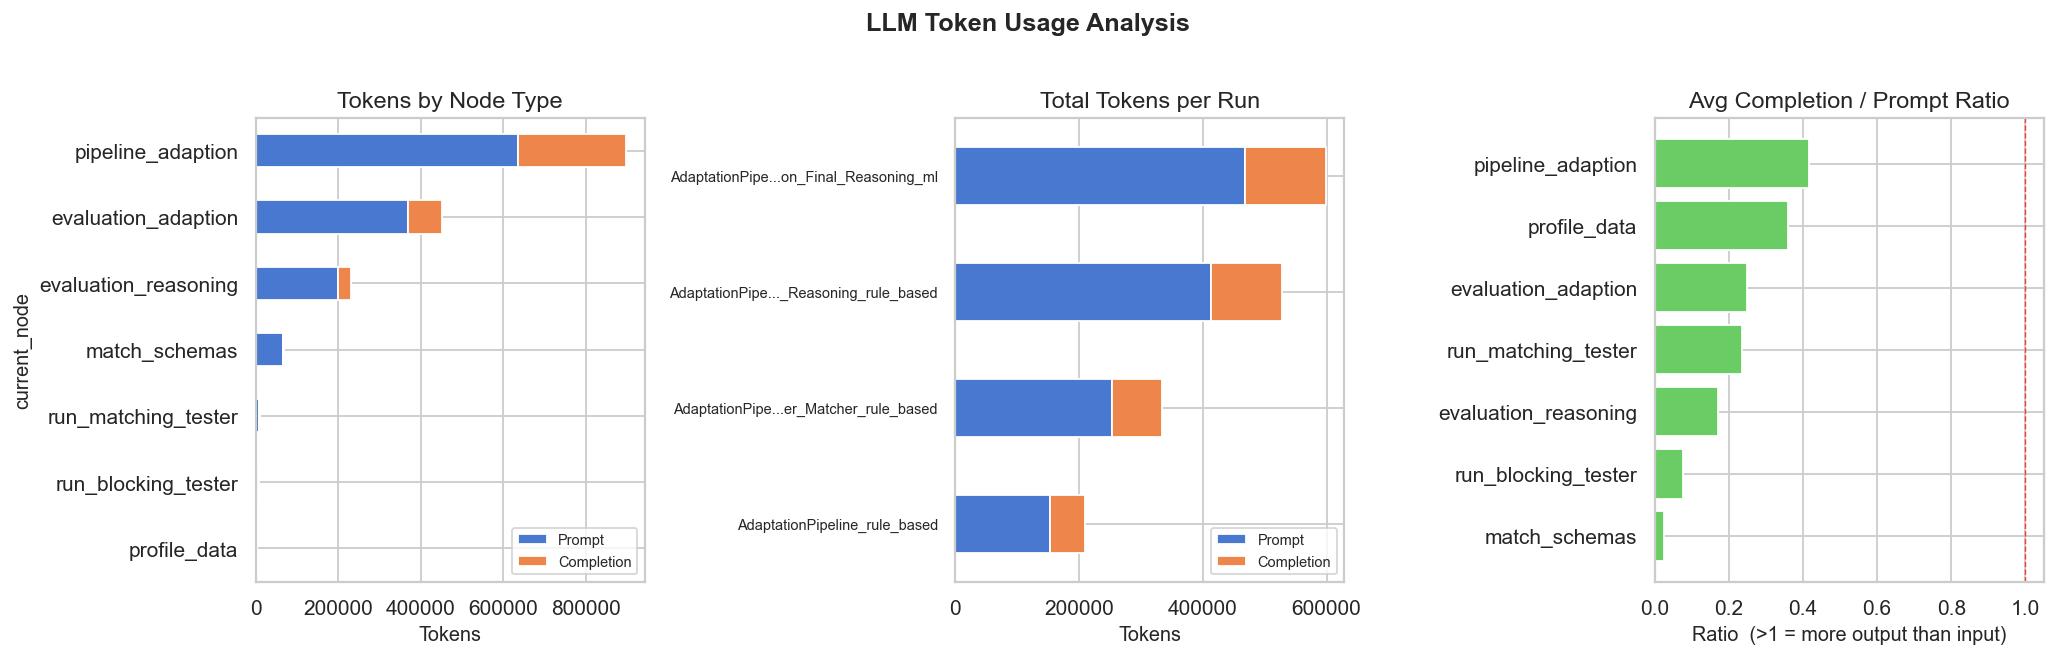

label,prompt_tokens,completion_tokens,total_tokens,prompt_%
AdaptationPipe..._Reasoning_rule_based,412638,115944,"528,582",78.1%
AdaptationPipe...er_Matcher_rule_based,254165,79805,"333,970",76.1%
AdaptationPipe...on_Final_Reasoning_ml,468781,129875,"598,656",78.3%
AdaptationPipeline_rule_based,153182,57323,"210,505",72.8%


In [56]:
token_nodes = all_nodes[all_nodes["total_tokens"] > 0].copy()

if token_nodes.empty:
    print("No token data found in logs.")
else:
    PALETTE = sns.color_palette("muted")
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 5a: Tokens per node type
    ax = axes[0]
    (token_nodes.groupby("current_node")[["prompt_tokens","completion_tokens"]]
                .sum().sort_values("prompt_tokens", ascending=True)
                .plot(kind="barh", stacked=True, ax=ax,
                      color=[PALETTE[0], PALETTE[1]], edgecolor="white"))
    ax.set_title("Tokens by Node Type")
    ax.set_xlabel("Tokens")
    ax.legend(["Prompt", "Completion"], loc="lower right", fontsize=8)

    # 5b: Total tokens per run — horizontal so labels are always readable
    ax2 = axes[1]
    (token_nodes.groupby("label")[["prompt_tokens","completion_tokens"]]
                .sum().sort_values("prompt_tokens", ascending=True)
                .plot(kind="barh", stacked=True, ax=ax2,
                      color=[PALETTE[0], PALETTE[1]], edgecolor="white"))
    ax2.set_title("Total Tokens per Run")
    ax2.set_xlabel("Tokens")
    ax2.set_ylabel("")
    ax2.tick_params(axis="y", labelsize=8)
    ax2.legend(["Prompt", "Completion"], fontsize=8)

    # 5c: Completion/prompt ratio per node
    ax3 = axes[2]
    token_nodes["ratio"] = (token_nodes["completion_tokens"] /
                            token_nodes["prompt_tokens"].replace(0, np.nan))
    ratio_by_node = token_nodes.groupby("current_node")["ratio"].mean().sort_values()
    ax3.barh(ratio_by_node.index, ratio_by_node.values,
             color=PALETTE[2], edgecolor="white")
    ax3.axvline(1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax3.set_title("Avg Completion / Prompt Ratio")
    ax3.set_xlabel("Ratio  (>1 = more output than input)")

    plt.suptitle("LLM Token Usage Analysis", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    tok_summary = (all_nodes.groupby("label")[["prompt_tokens","completion_tokens","total_tokens"]]
                            .sum().reset_index())
    tok_summary["prompt_%"] = (tok_summary["prompt_tokens"] / tok_summary["total_tokens"] * 100).round(1)
    display(tok_summary.style
            .background_gradient(subset=["total_tokens"], cmap="Blues")
            .format({"total_tokens": "{:,}", "prompt_%": "{:.1f}%"})
            .set_caption("Token Summary per Run")
            .hide(axis="index"))

---
## 6 · Pipeline Type Evaluation

Comparative analysis across pipeline types — accuracy progression, delta per iteration step, efficiency, and configuration metrics.

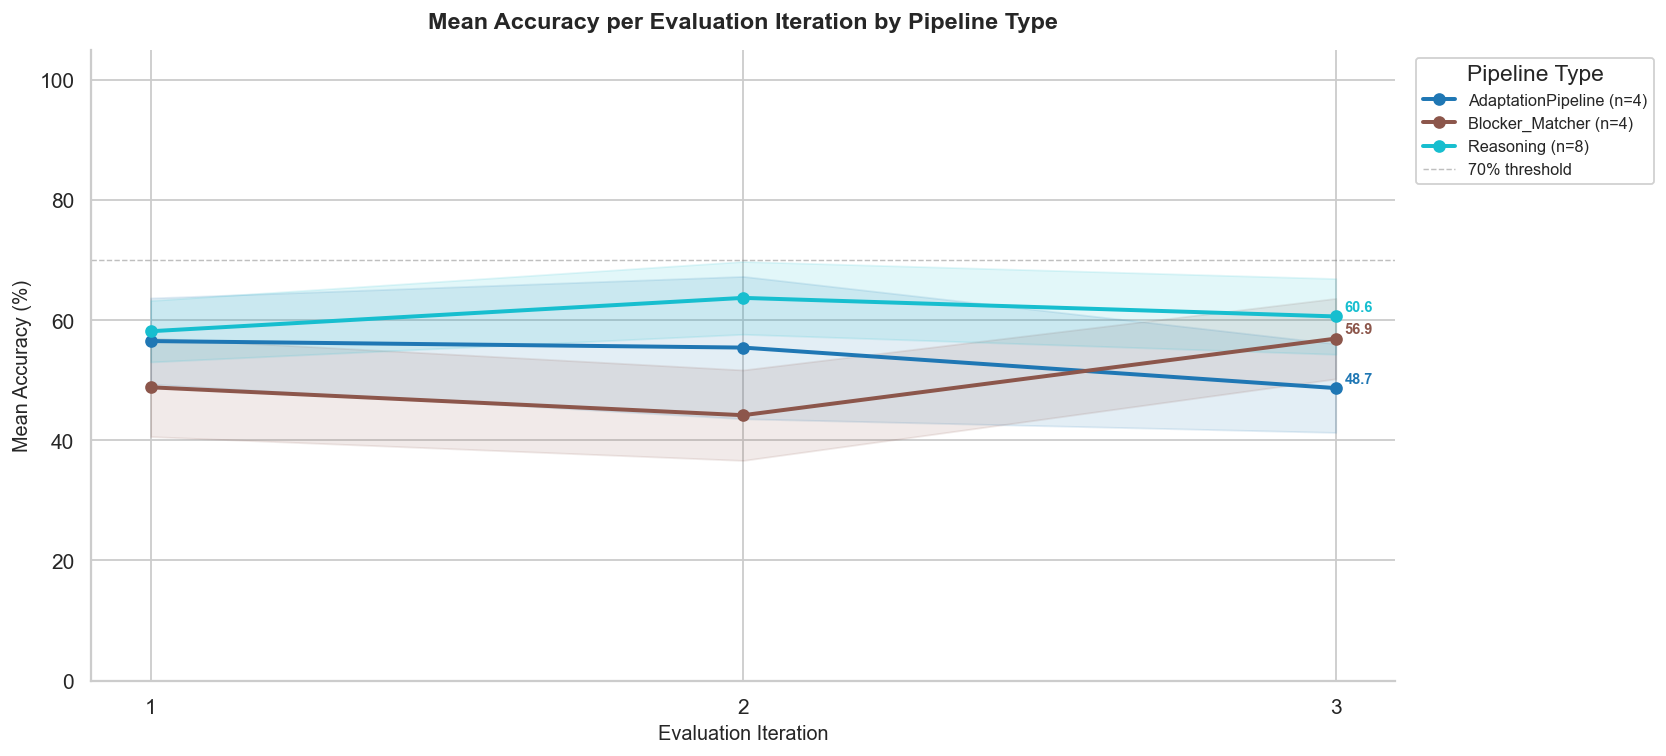

In [57]:
# ── 6a: Mean accuracy per iteration by pipeline type ─────────────────────────
if all_eval.empty or all_eval["accuracy_pct"].isna().all() or not pipeline_types:
    print("No pipeline type / accuracy data available.")
else:
    fig, ax = plt.subplots(figsize=(13, 6))

    for pt in pipeline_types:
        grp = all_eval[all_eval["pipeline_type"] == pt]
        mean_acc = (grp.groupby("eval_iteration")["accuracy_pct"]
                       .agg(mean="mean",
                            sem=lambda x: x.std() / max(len(x)**0.5, 1))
                       .reset_index())
        color    = PT_COLOR[pt]
        n_pt     = grp["run_id"].nunique()
        ax.plot(mean_acc["eval_iteration"], mean_acc["mean"],
                marker="o", linewidth=2.2, color=color,
                label=f"{pt} (n={n_pt})")
        ax.fill_between(mean_acc["eval_iteration"],
                        mean_acc["mean"] - mean_acc["sem"],
                        mean_acc["mean"] + mean_acc["sem"],
                        color=color, alpha=0.12)
        last = mean_acc.iloc[-1]
        ax.annotate(f"{last['mean']:.1f}",
                    xy=(last["eval_iteration"], last["mean"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=8, color=color, fontweight="bold")

    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8,
               alpha=0.5, label="70% threshold")
    ax.set_title("Mean Accuracy per Evaluation Iteration by Pipeline Type",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Evaluation Iteration")
    ax.set_ylabel("Mean Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Pipeline Type", fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()


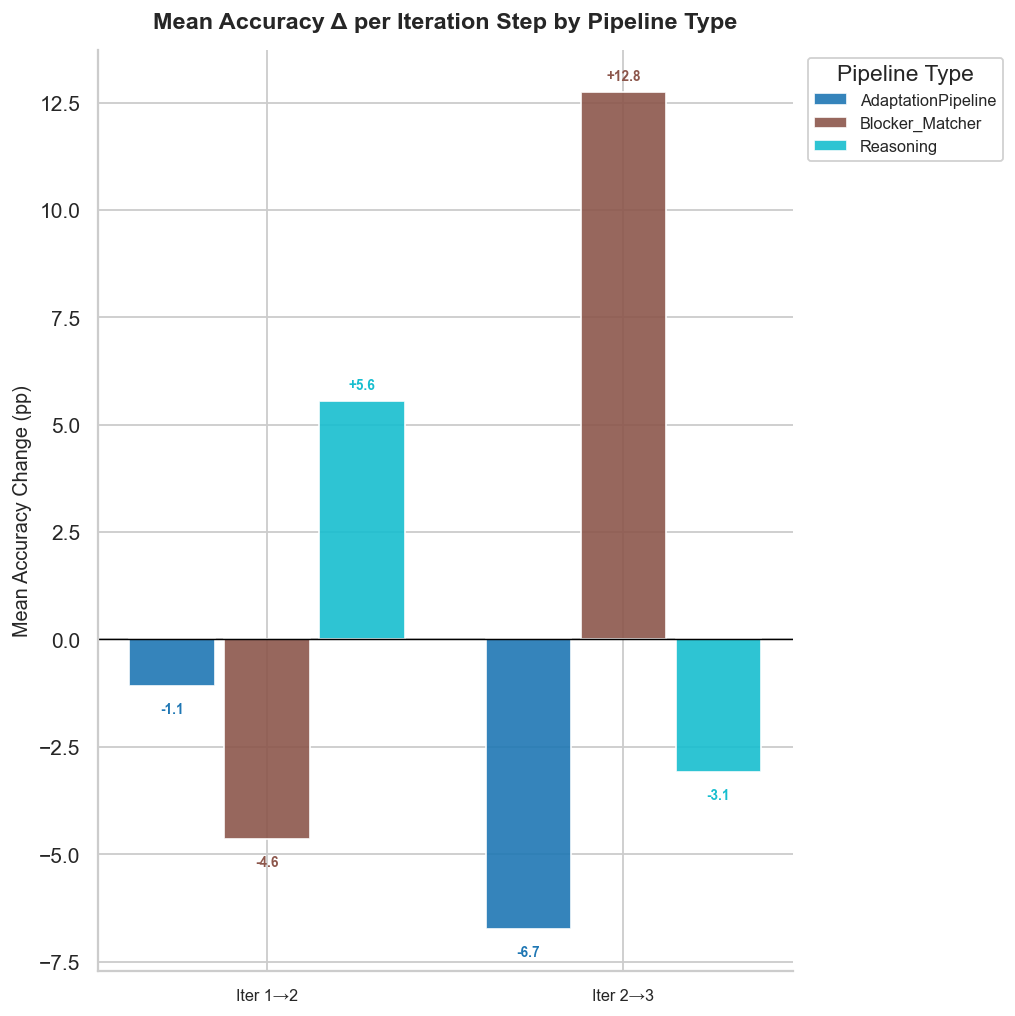

In [58]:
# ── 6b: Mean accuracy delta per step, grouped by pipeline type ───────────────
delta_rows_pt = []
for run_id, grp in all_eval.groupby("run_id"):
    pt    = grp["pipeline_type"].iloc[0]
    grp_s = grp.sort_values("eval_iteration").reset_index(drop=True)
    for j in range(1, len(grp_s)):
        p, c = grp_s.loc[j-1, "accuracy_pct"], grp_s.loc[j, "accuracy_pct"]
        if p is not None and c is not None:
            delta_rows_pt.append({
                "step":          f"Iter {j}\u2192{j+1}",
                "delta":         c - p,
                "pipeline_type": pt,
            })

if delta_rows_pt:
    df_delta_pt = pd.DataFrame(delta_rows_pt)
    steps       = sorted(df_delta_pt["step"].unique())
    n_pt        = len(pipeline_types)
    width       = 0.8 / max(n_pt, 1)
    offsets     = [i * width - (n_pt - 1) * width / 2 for i in range(n_pt)]

    fig, ax = plt.subplots(figsize=(max(8, len(steps) * n_pt * 0.9), 8))

    for i, pt in enumerate(sorted(pipeline_types)):
        grp   = df_delta_pt[df_delta_pt["pipeline_type"] == pt]
        means = grp.groupby("step")["delta"].mean().reindex(steps).fillna(0)
        cnts  = grp.groupby("step")["delta"].count().reindex(steps).fillna(0)
        x     = [j + offsets[i] for j in range(len(steps))]
        bars  = ax.bar(x, means.values, width=width * 0.9,
                       color=PT_COLOR[pt], edgecolor="white",
                       label=pt, alpha=0.9)
        for bar, val in zip(bars, means.values):
            if abs(val) > 0.05:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        val + (0.2 if val >= 0 else -0.7),
                        f"{val:+.1f}", ha="center", va="bottom",
                        fontsize=7.5, fontweight="bold", color=PT_COLOR[pt])

    ax.set_xticks(range(len(steps)))
    ax.set_xticklabels(steps, fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Mean Accuracy \u0394 per Iteration Step by Pipeline Type",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Mean Accuracy Change (pp)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Pipeline Type", fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough eval iterations to compute deltas.")


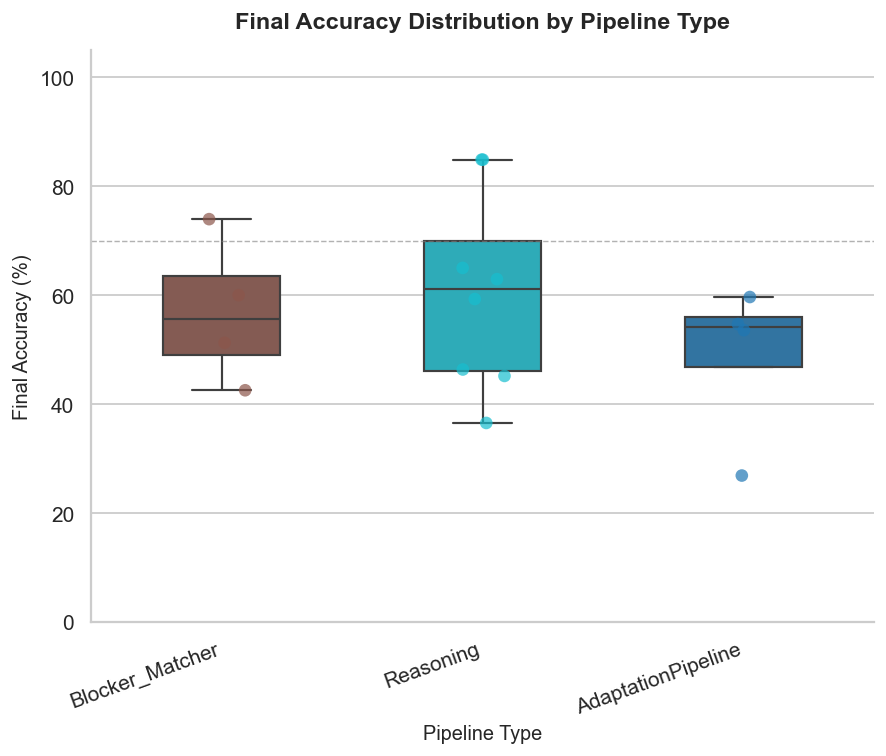


Pairwise t-tests (final accuracy):
  Pair                                            t-stat     p-value    sig
  ------------------------------------------------------------------------
  AdaptationPipeline vs Blocker_Matcher           -0.826      0.4406   n.s.
  AdaptationPipeline vs Reasoning                 -1.228      0.2575   n.s.
  Blocker_Matcher vs Reasoning                    -0.401      0.6987   n.s.


In [59]:
# ── 6c: Final accuracy distribution per pipeline type (box + strip) ──────────
if not all_eval.empty and pipeline_types:
    # Get final accuracy per run
    final_acc = (all_eval.sort_values("eval_iteration")
                         .groupby("run_id")
                         .last()
                         .reset_index()[["run_id","pipeline_type","accuracy_pct"]]
                         .dropna(subset=["accuracy_pct"]))

    fig, ax = plt.subplots(figsize=(max(7, len(pipeline_types) * 1.8), 6))
    sns.boxplot(data=final_acc, x="pipeline_type", y="accuracy_pct",
                palette=PT_COLOR, width=0.45, fliersize=0,
                linewidth=1.2, ax=ax)
    sns.stripplot(data=final_acc, x="pipeline_type", y="accuracy_pct",
                  palette=PT_COLOR, jitter=True, size=7,
                  alpha=0.7, ax=ax)
    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, alpha=0.6,
               label="70% threshold")
    ax.set_title("Final Accuracy Distribution by Pipeline Type",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Pipeline Type")
    ax.set_ylabel("Final Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # Statistical significance: pairwise t-tests if >= 2 types with >= 2 runs each
    groups = [grp["accuracy_pct"].values
              for _, grp in final_acc.groupby("pipeline_type")
              if len(grp) >= 2]
    labels_g = [pt for pt, grp in final_acc.groupby("pipeline_type")
                if len(grp) >= 2]
    if len(groups) >= 2:
        print("\nPairwise t-tests (final accuracy):")
        print(f"  {'Pair':<45} {'t-stat':>8}  {'p-value':>10}  {'sig':>5}")
        print("  " + "-"*72)
        from itertools import combinations
        for (i, j) in combinations(range(len(groups)), 2):
            t, p = stats.ttest_ind(groups[i], groups[j], equal_var=False)
            sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
            pair = f"{labels_g[i]} vs {labels_g[j]}"
            print(f"  {pair:<45} {t:>8.3f}  {p:>10.4f}  {sig:>5}")


pipeline_type,runs,mean_final_acc,mean_gain_pp,mean_iters,mean_tokens,mean_duration_min,mean_tokens_per_pp,mean_acc_per_token_k,mean_acc_per_min
Reasoning,8,60.63%,+2.46pp,3.0,"140,905",37.0 min,"7,612,099",0.463,1.97
Blocker_Matcher,4,56.94%,+8.11pp,3.0,"83,492",41.3 min,"4,387,294",0.729,2.07
AdaptationPipeline,4,48.70%,-7.83pp,3.0,"52,626",12.3 min,"5,262,625",0.950,5.15


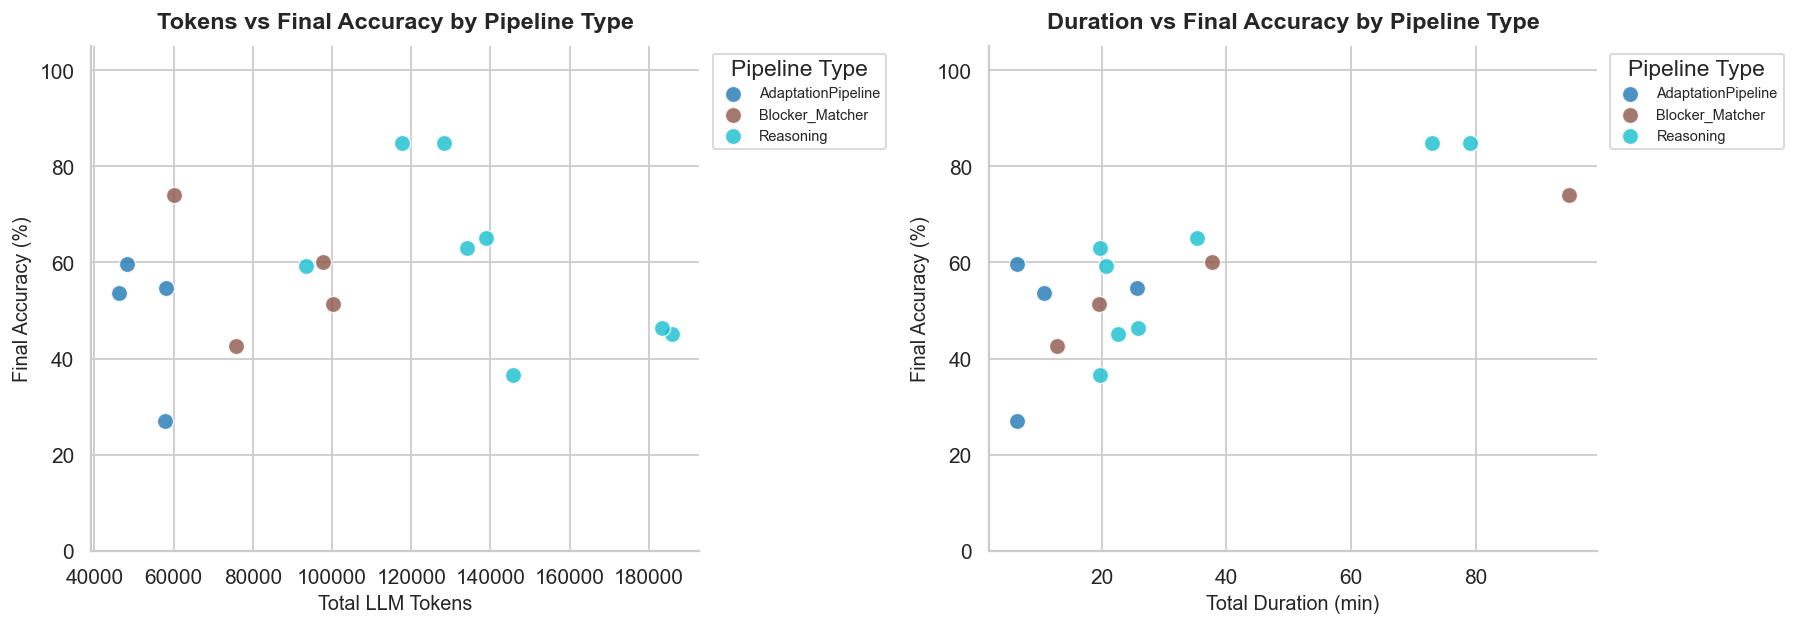

In [60]:
# ── 6d: Efficiency metrics by pipeline type ───────────────────────────────────
if not all_eval.empty and pipeline_types:
    eff_rows = []
    for run_id, r in runs.items():
        pt         = r["pipeline_type"]
        accuracies = [e["accuracy_pct"] for e in r["eval_runs"] if e["accuracy_pct"] is not None]
        tokens     = int(r["nodes"]["total_tokens"].sum())
        duration   = r["time_summary"]["total_duration_s"]
        n_iters    = len(r["eval_runs"])
        final_acc  = accuracies[-1] if accuracies else None
        gain       = (accuracies[-1] - accuracies[0]) if len(accuracies) > 1 else 0.0

        eff_rows.append({
            "pipeline_type":      pt,
            "run_id":             run_id,
            "final_acc":          final_acc,
            "gain_pp":            gain,
            "n_iters":            n_iters,
            "total_tokens":       tokens,
            "duration_min":       duration / 60,
            "tokens_per_pp":      tokens / max(gain, 0.01),       # tokens spent per pp gained
            "acc_per_token_k":    (final_acc or 0) / max(tokens / 1000, 0.01),  # acc per 1k tokens
            "acc_per_min":        (final_acc or 0) / max(duration / 60, 0.01),
        })

    df_eff = pd.DataFrame(eff_rows)

    # Summary by pipeline type
    eff_summary = (df_eff.groupby("pipeline_type")
                         .agg(
                             runs=("run_id", "count"),
                             mean_final_acc=("final_acc", "mean"),
                             mean_gain_pp=("gain_pp", "mean"),
                             mean_iters=("n_iters", "mean"),
                             mean_tokens=("total_tokens", "mean"),
                             mean_duration_min=("duration_min", "mean"),
                             mean_tokens_per_pp=("tokens_per_pp", "mean"),
                             mean_acc_per_token_k=("acc_per_token_k", "mean"),
                             mean_acc_per_min=("acc_per_min", "mean"),
                         )
                         .reset_index()
                         .sort_values("mean_final_acc", ascending=False))

    display(
        eff_summary.style
        .background_gradient(subset=["mean_final_acc"],       cmap="YlGn",  vmin=40, vmax=100)
        .background_gradient(subset=["mean_gain_pp"],         cmap="Blues")
        .background_gradient(subset=["mean_tokens"],          cmap="Oranges")
        .background_gradient(subset=["mean_acc_per_token_k"], cmap="Greens")
        .background_gradient(subset=["mean_acc_per_min"],     cmap="Purples")
        .format({
            "mean_final_acc":       "{:.2f}%",
            "mean_gain_pp":         "{:+.2f}pp",
            "mean_iters":           "{:.1f}",
            "mean_tokens":          "{:,.0f}",
            "mean_duration_min":    "{:.1f} min",
            "mean_tokens_per_pp":   "{:,.0f}",
            "mean_acc_per_token_k": "{:.3f}",
            "mean_acc_per_min":     "{:.2f}",
        })
        .set_caption("Efficiency Summary by Pipeline Type")
        .hide(axis="index")
    )

    # Scatter: tokens vs final accuracy coloured by pipeline type
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, xcol, xlabel in zip(axes,
            ["total_tokens", "duration_min"],
            ["Total LLM Tokens", "Total Duration (min)"]):
        for pt in pipeline_types:
            sub = df_eff[df_eff["pipeline_type"] == pt]
            ax.scatter(sub[xcol], sub["final_acc"],
                       color=PT_COLOR[pt], label=pt,
                       s=80, alpha=0.8, edgecolors="white", linewidth=0.8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Final Accuracy (%)")
        ax.set_ylim(0, 105)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(title="Pipeline Type", fontsize=8,
                  bbox_to_anchor=(1.01, 1), loc="upper left")

    axes[0].set_title("Tokens vs Final Accuracy by Pipeline Type",
                      fontweight="bold", pad=10)
    axes[1].set_title("Duration vs Final Accuracy by Pipeline Type",
                      fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()


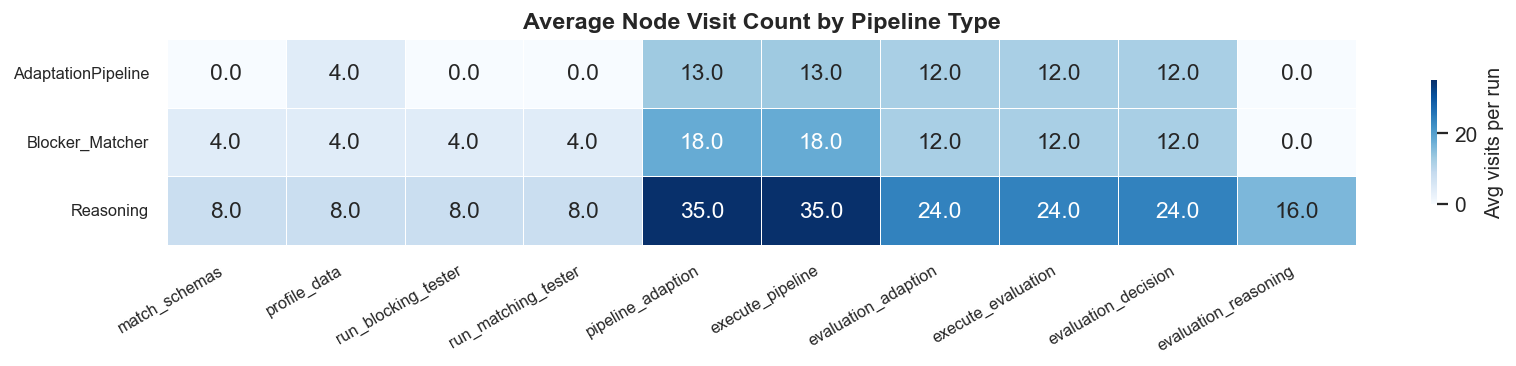

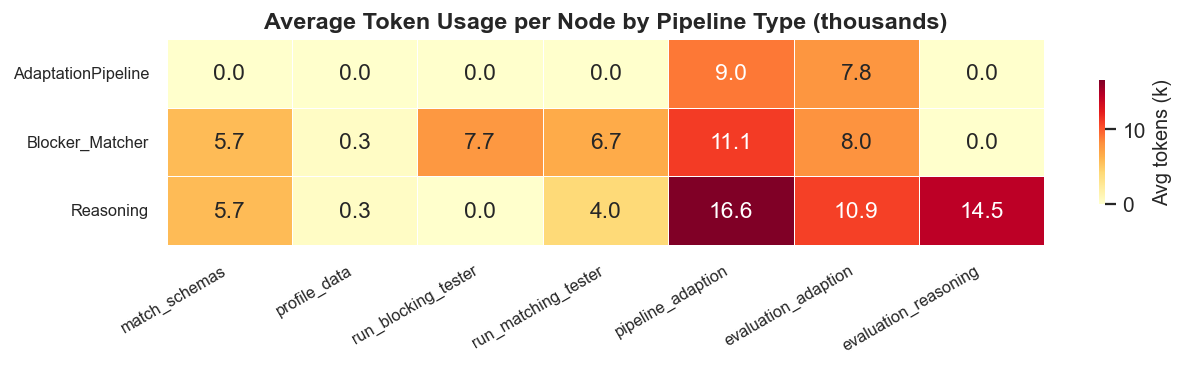

In [41]:
# ── 6e: Node visit profile by pipeline type ───────────────────────────────────
if not all_nodes.empty and pipeline_types:
    visit_pivot = (all_nodes.groupby(["pipeline_type","current_node"])
                            .size().reset_index(name="visits")
                            .pivot_table(index="pipeline_type", columns="current_node",
                                         values="visits", aggfunc="mean")
                            .fillna(0))
    cols_v = ([c for c in NODE_ORDER if c in visit_pivot.columns] +
              [c for c in visit_pivot.columns if c not in NODE_ORDER])
    visit_pivot = visit_pivot[cols_v]

    fig, ax = plt.subplots(figsize=(max(10, len(cols_v) * 1.3),
                                    max(3, len(visit_pivot) * 0.8)))
    sns.heatmap(visit_pivot, annot=True, fmt=".1f", cmap="Blues",
                linewidths=0.4, linecolor="white", ax=ax,
                cbar_kws={"label": "Avg visits per run", "shrink": 0.6})
    ax.set_title("Average Node Visit Count by Pipeline Type",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Token usage by pipeline type and node
    tok_pivot = (all_nodes[all_nodes["total_tokens"] > 0]
                 .groupby(["pipeline_type","current_node"])["total_tokens"]
                 .mean().reset_index()
                 .pivot_table(index="pipeline_type", columns="current_node",
                              values="total_tokens", aggfunc="mean")
                 .fillna(0))
    cols_t = ([c for c in NODE_ORDER if c in tok_pivot.columns] +
              [c for c in tok_pivot.columns if c not in NODE_ORDER])
    tok_pivot = tok_pivot[cols_t]

    if not tok_pivot.empty:
        fig, ax = plt.subplots(figsize=(max(10, len(cols_t) * 1.3),
                                        max(3, len(tok_pivot) * 0.8)))
        sns.heatmap(tok_pivot / 1000, annot=True, fmt=".1f", cmap="YlOrRd",
                    linewidths=0.4, linecolor="white", ax=ax,
                    cbar_kws={"label": "Avg tokens (k)", "shrink": 0.6})
        ax.set_title("Average Token Usage per Node by Pipeline Type (thousands)",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()


In [42]:
# ── 6f: Summary table — final accuracy by pipeline type ───────────────────────
if not all_eval.empty and pipeline_types:
    final_per_run = (all_eval.sort_values("eval_iteration")
                             .groupby("run_id")
                             .last()
                             .reset_index())

    summary_rows = []
    for pt in sorted(pipeline_types):
        grp = final_per_run[final_per_run["pipeline_type"] == pt]["accuracy_pct"].dropna()
        if grp.empty:
            continue
        # gain per run
        gains = []
        for rid, r in runs.items():
            if r["pipeline_type"] != pt:
                continue
            accs = [e["accuracy_pct"] for e in r["eval_runs"] if e["accuracy_pct"] is not None]
            if len(accs) > 1:
                gains.append(accs[-1] - accs[0])

        summary_rows.append({
            "Pipeline Type":      pt,
            "Runs":               len(grp),
            "Mean Final Acc (%)": round(grp.mean(), 2),
            "Std (pp)":           round(grp.std(), 2),
            "Min (%)":            round(grp.min(), 2),
            "Max (%)":            round(grp.max(), 2),
            "Mean Gain (pp)":     round(np.mean(gains), 2) if gains else 0.0,
            "% Runs ≥ 70%":       round((grp >= 70).mean() * 100, 1),
        })

    df_pt_summary = (pd.DataFrame(summary_rows)
                       .sort_values("Mean Final Acc (%)", ascending=False))
    display(
        df_pt_summary.style
        .background_gradient(subset=["Mean Final Acc (%)"], cmap="YlGn",  vmin=40, vmax=100)
        .background_gradient(subset=["Mean Gain (pp)"],     cmap="Blues")
        .background_gradient(subset=["% Runs ≥ 70%"],       cmap="Greens", vmin=0, vmax=100)
        .background_gradient(subset=["Std (pp)"],            cmap="Reds",   vmin=0)
        .format({
            "Mean Final Acc (%)": "{:.2f}",
            "Std (pp)":           "{:.2f}",
            "Min (%)":            "{:.2f}",
            "Max (%)":            "{:.2f}",
            "Mean Gain (pp)":     "{:+.2f}",
            "% Runs ≥ 70%":       "{:.1f}%",
        })
        .set_caption("Final Accuracy Summary by Pipeline Type")
        .hide(axis="index")
    )


Pipeline Type,Runs,Mean Final Acc (%),Std (pp),Min (%),Max (%),Mean Gain (pp),% Runs ≥ 70%
Reasoning,8,60.63,17.82,36.55,84.87,+2.46,25.0%
Blocker_Matcher,4,56.94,13.39,42.55,73.95,+8.10,25.0%
AdaptationPipeline,4,48.70,14.78,26.90,59.66,-7.83,0.0%


---
## 7 · Blocking Configuration Analysis

In [62]:
if all_blocking.empty:
    print("No blocking config data.")
else:
    display(
        all_blocking[["label","pair","strategy","columns",
                      "pair_completeness","num_candidates","is_acceptable"]]
        .sort_values(["label","pair"])
        .style
        .background_gradient(subset=["pair_completeness"], cmap="YlGn", vmin=0.7, vmax=1.0)
        .background_gradient(subset=["num_candidates"],    cmap="Blues")
        .format({"pair_completeness": "{:.3f}", "num_candidates": "{:,.0f}"})
        .set_caption("Blocking Configuration Details")
        .hide(axis="index")
    )

label,pair,strategy,columns,pair_completeness,num_candidates,is_acceptable
AdaptationPipe..._Reasoning_rule_based,dbpedia_sales,semantic_similarity,"name, platform, releaseYear",0.913,"929,573",True
AdaptationPipe..._Reasoning_rule_based,discogs_lastfm,semantic_similarity,"name, artist",0.964,"225,831",True
AdaptationPipe..._Reasoning_rule_based,discogs_musicbrainz,sorted_neighbourhood,name,0.900,"115,280",True
AdaptationPipe..._Reasoning_rule_based,goodreads_small_amazon_small,semantic_similarity,"title, author, publish_year",0.998,"199,823",True
AdaptationPipe..._Reasoning_rule_based,kaggle_small_uber_eats_small,semantic_similarity,"name_norm, city, state",1.000,"199,719",True
AdaptationPipe..._Reasoning_rule_based,kaggle_small_yelp_small,exact_match_multi,"phone_e164, postal_code",1.000,179,True
AdaptationPipe..._Reasoning_rule_based,metabooks_small_amazon_small,semantic_similarity,"title, author, publisher",0.994,"149,824",True
AdaptationPipe..._Reasoning_rule_based,metabooks_small_goodreads_small,semantic_similarity,"title, author, publisher",0.995,"199,106",True
AdaptationPipe..._Reasoning_rule_based,metacritic_dbpedia,semantic_similarity,"name, developer, platform",0.963,"409,850",True
AdaptationPipe..._Reasoning_rule_based,metacritic_sales,semantic_similarity,"name, platform, releaseYear",1.000,"409,504",True


---
## 8 · Matching Configuration & F1 Scores

In [63]:
if all_matching.empty:
    print("No matching config data.")
else:
    display(
        all_matching[["label","pair","threshold","f1","n_comparators"]]
        .sort_values(["label","pair"])
        .style
        .background_gradient(subset=["f1"], cmap="YlGn", vmin=0.5, vmax=1.0)
        .format({"f1": "{:.4f}", "threshold": "{:.2f}"})
        .set_caption("Matching Strategy Details")
        .hide(axis="index")
    )

label,pair,threshold,f1,n_comparators
AdaptationPipe..._Reasoning_rule_based,dbpedia_sales,0.75,0.8644,4
AdaptationPipe..._Reasoning_rule_based,discogs_lastfm,0.60,0.8966,4
AdaptationPipe..._Reasoning_rule_based,discogs_musicbrainz,0.70,0.8732,5
AdaptationPipe..._Reasoning_rule_based,goodreads_small_amazon_small,0.66,0.8029,4
AdaptationPipe..._Reasoning_rule_based,kaggle_small_uber_eats_small,0.75,0.8947,7
AdaptationPipe..._Reasoning_rule_based,kaggle_small_yelp_small,0.75,0.9831,7
AdaptationPipe..._Reasoning_rule_based,metabooks_small_amazon_small,0.72,0.8526,4
AdaptationPipe..._Reasoning_rule_based,metabooks_small_goodreads_small,0.68,0.8363,5
AdaptationPipe..._Reasoning_rule_based,metacritic_dbpedia,0.80,0.8867,4
AdaptationPipe..._Reasoning_rule_based,metacritic_sales,0.78,0.8845,6


---
## 9 · Error & Retry Analysis

In [45]:
exceptions  = all_nodes[all_nodes["next_node"].str.contains("EXCEPTION", na=False)].copy()
failed_exec = all_nodes[all_nodes["output_summary"].str.contains("failed", case=False, na=False)].copy()

print(f"{'OK ' if exceptions.empty  else 'ERR'}  Exception transitions : {len(exceptions)}")
print(f"{'OK ' if failed_exec.empty else 'ERR'}  Failed execution nodes: {len(failed_exec)}")

if not exceptions.empty:
    print("\nException transitions:")
    display(
        exceptions[["label","node_index","current_node","next_node",
                    "duration_seconds","output_summary"]]
        .sort_values("label")
        .style.set_caption("Exception Transitions").hide(axis="index")
    )

retry_rows = []
for run_id, r in runs.items():
    ndf = r["nodes"]
    retry_rows.append({
        "Run":                       r["label"],
        "execute_pipeline visits":   int((ndf["current_node"] == "execute_pipeline").sum()),
        "execute_evaluation visits": int((ndf["current_node"] == "execute_evaluation").sum()),
        "pipeline_adaption visits":  int((ndf["current_node"] == "pipeline_adaption").sum()),
        "eval_reasoning visits":     int((ndf["current_node"] == "evaluation_reasoning").sum()),
        "exception transitions":     int(ndf["next_node"].str.contains("EXCEPTION", na=False).sum()),
    })

print("\nRetry & Iteration Counts:")
display(
    pd.DataFrame(retry_rows).style
    .background_gradient(subset=["execute_pipeline visits",
                                  "execute_evaluation visits",
                                  "pipeline_adaption visits"], cmap="YlOrRd")
    .background_gradient(subset=["exception transitions"], cmap="Reds")
    .set_caption("Retry & Iteration Counts per Run")
    .hide(axis="index")
)

OK   Exception transitions : 0
ERR  Failed execution nodes: 19

Retry & Iteration Counts:


Run,execute_pipeline visits,execute_evaluation visits,pipeline_adaption visits,eval_reasoning visits,exception transitions
AdaptationPipe...er_Matcher_rule_based,6,3,6,0,0
AdaptationPipe...er_Matcher_rule_based,3,3,3,0,0
AdaptationPipe...er_Matcher_rule_based,4,3,4,0,0
AdaptationPipe...er_Matcher_rule_based,5,3,5,0,0
AdaptationPipe...on_Final_Reasoning_ml,4,3,4,2,0
AdaptationPipe...on_Final_Reasoning_ml,5,3,5,2,0
AdaptationPipe...on_Final_Reasoning_ml,4,3,4,2,0
AdaptationPipe...on_Final_Reasoning_ml,4,3,4,2,0
AdaptationPipe..._Reasoning_rule_based,5,3,5,2,0
AdaptationPipe..._Reasoning_rule_based,6,3,6,2,0


---
## 10 · Use Case Analysis

Statistics and comparisons broken down by `use_case` — run distribution, accuracy, cost, duration, and pipeline-type mix.

In [47]:
# ── 11a: Use-case summary table ───────────────────────────────────────────────
if not all_eval.empty and use_cases:
    uc_rows = []
    for uc in use_cases:
        uc_runs   = {rid: r for rid, r in runs.items() if r["use_case"] == uc}
        accs      = []
        init_accs = []
        tokens_l  = []
        dur_l     = []
        iters_l   = []
        pts       = set()
        for r in uc_runs.values():
            ev = [e["accuracy_pct"] for e in r["eval_runs"] if e["accuracy_pct"] is not None]
            if ev:
                accs.append(ev[-1])
                init_accs.append(ev[0])
            tokens_l.append(int(r["nodes"]["total_tokens"].sum()))
            dur_l.append(r["time_summary"]["total_duration_s"] / 60)
            iters_l.append(len(r["eval_runs"]))
            pts.add(r["pipeline_type"])

        uc_rows.append({
            "Use Case":            uc,
            "Runs":                len(uc_runs),
            "Pipeline Types":      ", ".join(sorted(pts)),
            "Mean Init Acc (%)": round(float(np.mean(init_accs)), 2) if init_accs else None,
            "Mean Final Acc (%)": round(float(np.mean(accs)), 2)     if accs else None,
            "Best Final Acc (%)": round(float(np.max(accs)), 2)      if accs else None,
            "Mean Gain (pp)":    round(float(np.mean([a - b for a, b in zip(accs, init_accs)])), 2) if len(accs) > 0 and len(init_accs) == len(accs) else None,
            "Mean Iters":        round(float(np.mean(iters_l)), 1)   if iters_l else None,
            "Mean Tokens":       round(float(np.mean(tokens_l)))     if tokens_l else None,
            "Mean Duration (min)": round(float(np.mean(dur_l)), 1)   if dur_l else None,
        })

    uc_df = pd.DataFrame(uc_rows).sort_values("Mean Final Acc (%)", ascending=False)

    display(
        uc_df.style
        .background_gradient(subset=["Mean Final Acc (%)"], cmap="YlGn",  vmin=40, vmax=100)
        .background_gradient(subset=["Mean Gain (pp)"],     cmap="Blues")
        .background_gradient(subset=["Mean Tokens"],        cmap="Oranges")
        .background_gradient(subset=["Mean Duration (min)"],cmap="Purples")
        .format({
            "Mean Init Acc (%)": "{:.2f}",
            "Mean Final Acc (%)": "{:.2f}",
            "Best Final Acc (%)": "{:.2f}",
            "Mean Gain (pp)":    "{:+.2f}",
            "Mean Tokens":       "{:,.0f}",
        }, na_rep="—")
        .set_caption("Use Case Summary")
        .hide(axis="index")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "14px"),("font-weight","bold")]}])
    )
else:
    print("No use-case data available.")

Use Case,Runs,Pipeline Types,Mean Init Acc (%),Mean Final Acc (%),Best Final Acc (%),Mean Gain (pp),Mean Iters,Mean Tokens,Mean Duration (min)
Games,4,"AdaptationPipeline, Blocker_Matcher, Reasoning",49.79,75.84,84.87,+26.05,3.000000,"88,596",63.300000
Books,4,"AdaptationPipeline, Blocker_Matcher, Reasoning",61.96,59.46,65.00,-2.50,3.000000,"94,064",26.100000
Restaurants,4,"AdaptationPipeline, Blocker_Matcher, Reasoning",57.92,47.19,54.69,-10.73,3.000000,"125,752",21.700000
Music,4,"AdaptationPipeline, Blocker_Matcher, Reasoning",52.03,44.41,62.94,-7.62,3.000000,"109,517",16.400000


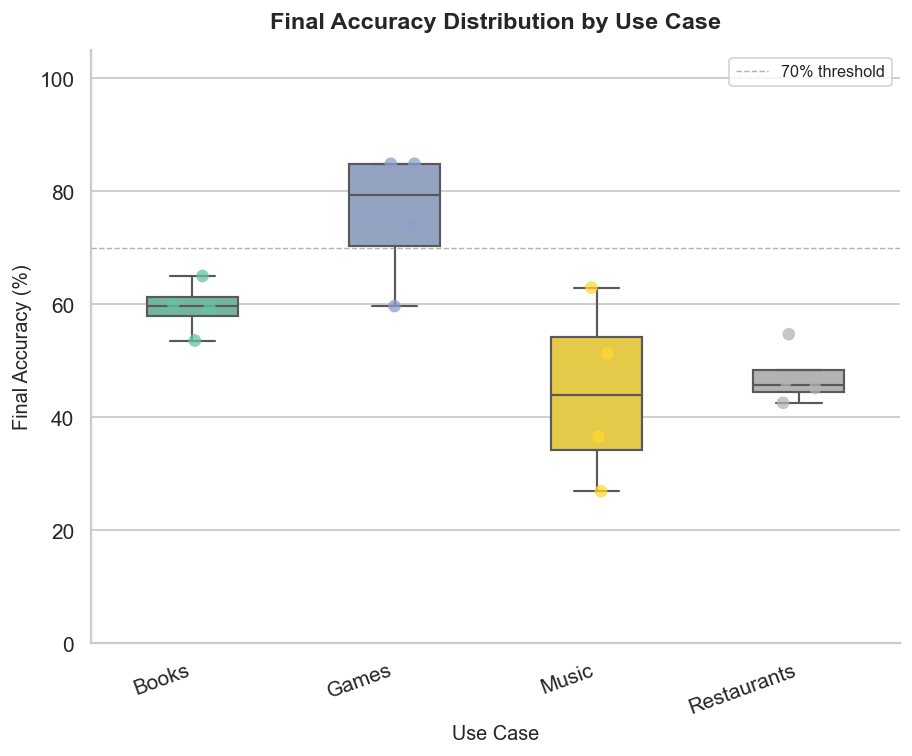

In [48]:
# ── 11b: Final accuracy distribution per use case (bar + individual runs) ─────
if not all_eval.empty and use_cases:
    final_acc_uc = (
        all_eval.sort_values("eval_iteration")
                .groupby("run_id").last().reset_index()
                [["run_id", "use_case", "pipeline_type", "accuracy_pct"]]
                .dropna(subset=["accuracy_pct"])
    )

    n_uc = len(use_cases)
    fig, ax = plt.subplots(figsize=(max(7, n_uc * 1.8), 6))
    sns.boxplot(data=final_acc_uc, x="use_case", y="accuracy_pct",
                palette=UC_COLOR, width=0.45, fliersize=0,
                linewidth=1.2, ax=ax, order=use_cases)
    sns.stripplot(data=final_acc_uc, x="use_case", y="accuracy_pct",
                  palette=UC_COLOR, jitter=True, size=7,
                  alpha=0.75, ax=ax, order=use_cases)
    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, alpha=0.6,
               label="70% threshold")
    ax.set_title("Final Accuracy Distribution by Use Case",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Use Case")
    ax.set_ylabel("Final Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

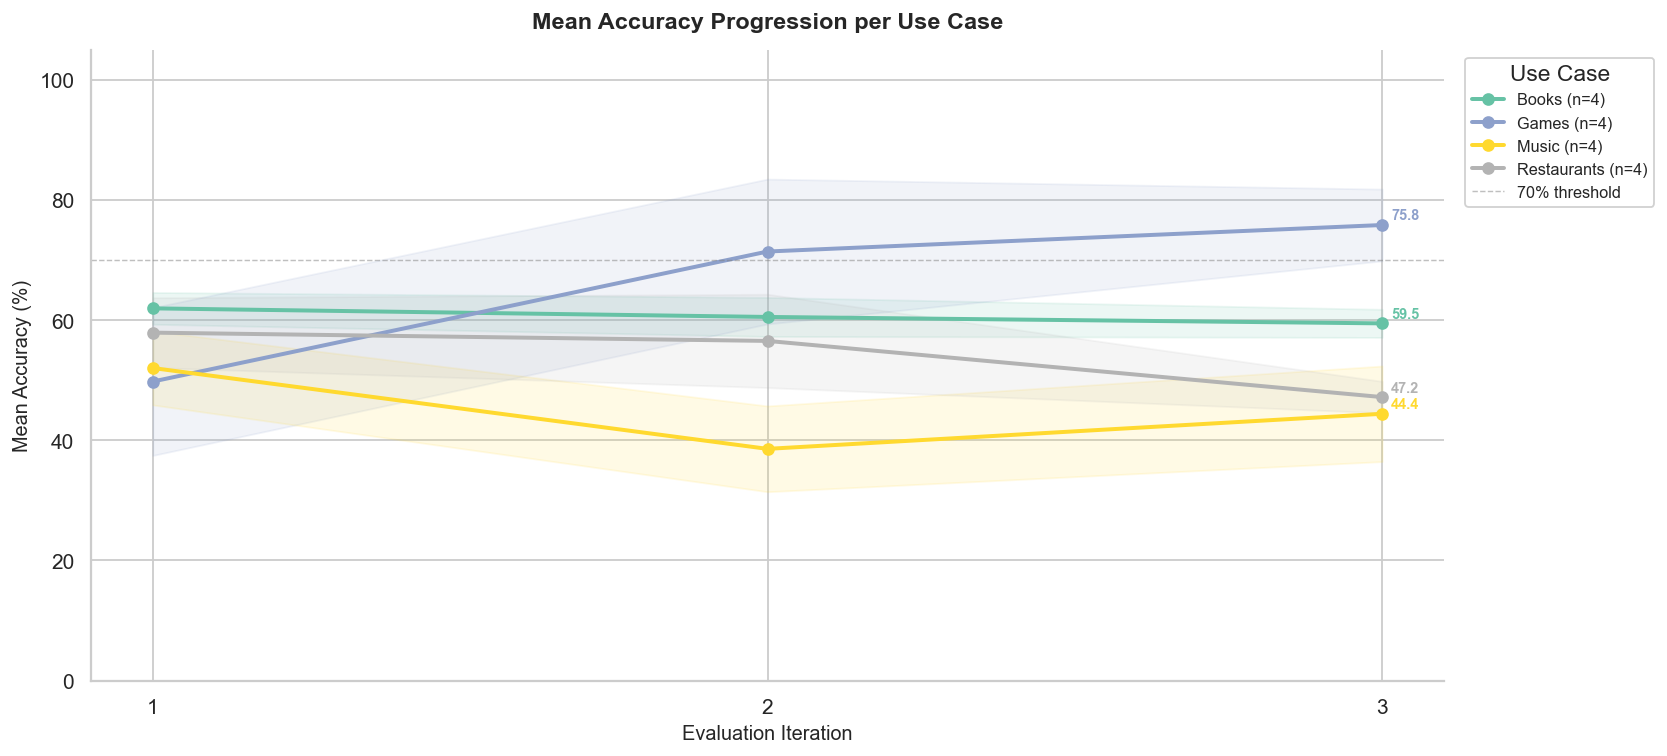

In [49]:
# ── 11c: Mean accuracy progression per use case ───────────────────────────────
if not all_eval.empty and len(use_cases) > 0:
    fig, ax = plt.subplots(figsize=(13, 6))

    for uc in use_cases:
        grp = all_eval[all_eval["use_case"] == uc]
        mean_acc = (
            grp.groupby("eval_iteration")["accuracy_pct"]
               .agg(mean="mean", sem=lambda x: x.std() / max(len(x)**0.5, 1))
               .reset_index()
        )
        color = UC_COLOR[uc]
        n_uc_runs = grp["run_id"].nunique()
        ax.plot(mean_acc["eval_iteration"], mean_acc["mean"],
                marker="o", linewidth=2.2, color=color,
                label=f"{uc} (n={n_uc_runs})")
        ax.fill_between(mean_acc["eval_iteration"],
                        mean_acc["mean"] - mean_acc["sem"],
                        mean_acc["mean"] + mean_acc["sem"],
                        color=color, alpha=0.12)
        last = mean_acc.iloc[-1]
        ax.annotate(f"{last['mean']:.1f}",
                    xy=(last["eval_iteration"], last["mean"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=8, color=color, fontweight="bold")

    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8,
               alpha=0.5, label="70% threshold")
    ax.set_title("Mean Accuracy Progression per Use Case",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Evaluation Iteration")
    ax.set_ylabel("Mean Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Use Case", fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()

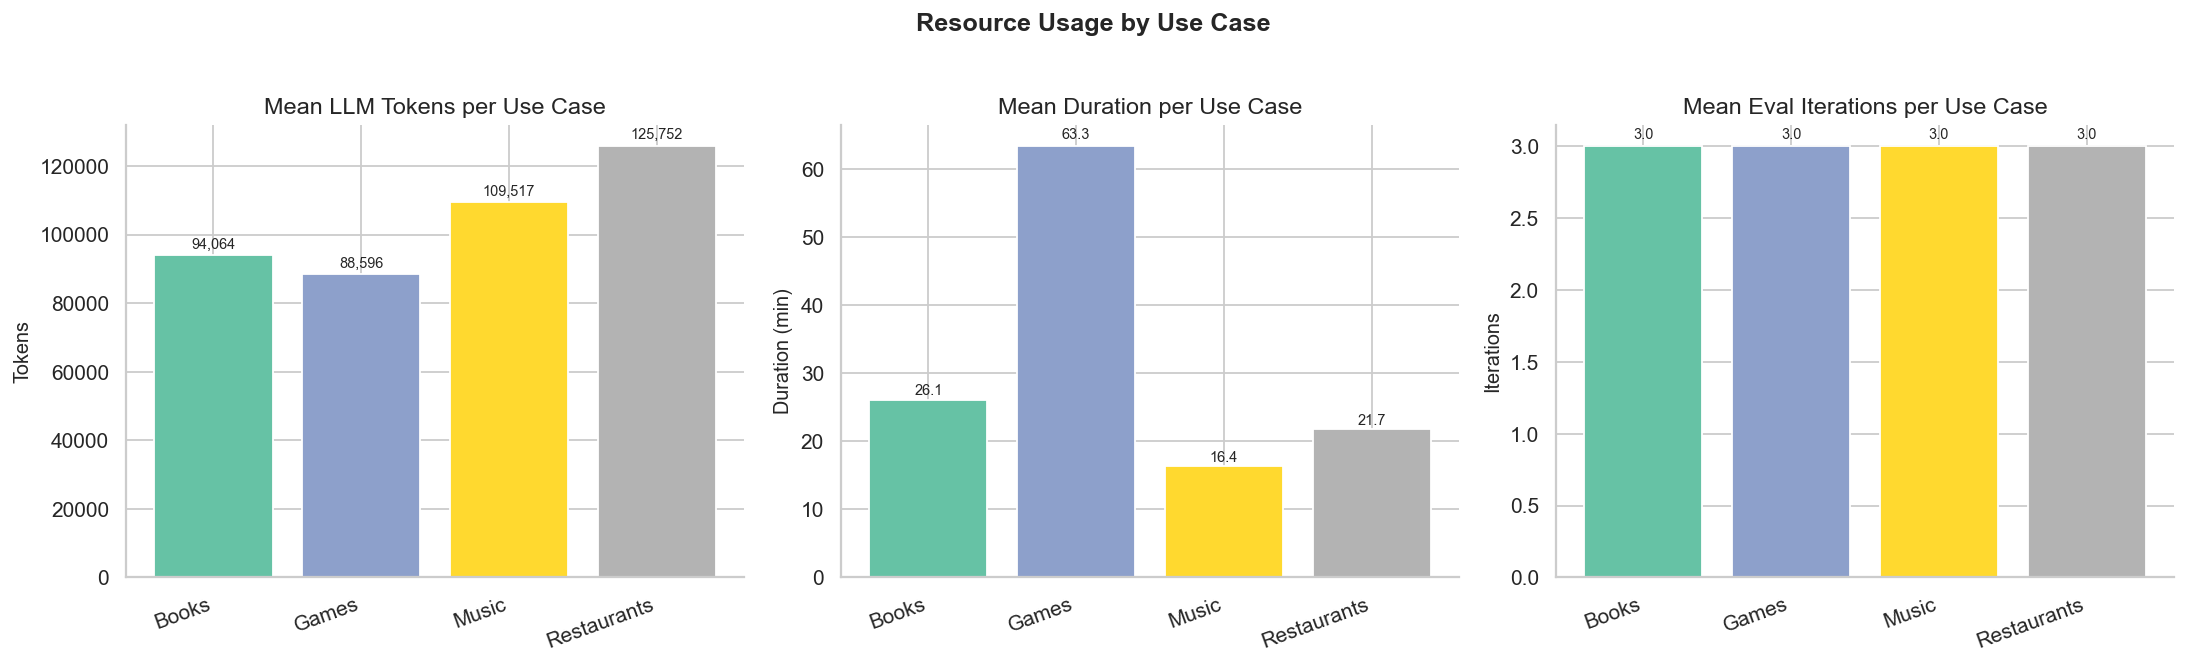

In [50]:
# ── 11d: Token & duration comparison across use cases ────────────────────────
if not all_eval.empty and use_cases:
    uc_eff_rows = []
    for rid, r in runs.items():
        ev = [e["accuracy_pct"] for e in r["eval_runs"] if e["accuracy_pct"] is not None]
        uc_eff_rows.append({
            "use_case":      r["use_case"],
            "pipeline_type": r["pipeline_type"],
            "final_acc":     ev[-1] if ev else None,
            "total_tokens":  int(r["nodes"]["total_tokens"].sum()),
            "duration_min":  r["time_summary"]["total_duration_s"] / 60,
            "n_iters":       len(r["eval_runs"]),
        })
    df_uc_eff = pd.DataFrame(uc_eff_rows)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Tokens per use case
    ax = axes[0]
    uc_tok = df_uc_eff.groupby("use_case")["total_tokens"].mean().reindex(use_cases)
    bars = ax.bar(use_cases, uc_tok.values,
                  color=[UC_COLOR[u] for u in use_cases], edgecolor="white")
    for bar, val in zip(bars, uc_tok.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=8)
    ax.set_title("Mean LLM Tokens per Use Case")
    ax.set_ylabel("Tokens")
    ax.set_xlabel("")
    ax.spines[["top", "right"]].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

    # Duration per use case
    ax2 = axes[1]
    uc_dur = df_uc_eff.groupby("use_case")["duration_min"].mean().reindex(use_cases)
    bars2 = ax2.bar(use_cases, uc_dur.values,
                    color=[UC_COLOR[u] for u in use_cases], edgecolor="white")
    for bar, val in zip(bars2, uc_dur.values):
        ax2.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=8)
    ax2.set_title("Mean Duration per Use Case")
    ax2.set_ylabel("Duration (min)")
    ax2.set_xlabel("")
    ax2.spines[["top", "right"]].set_visible(False)
    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

    # Iterations per use case
    ax3 = axes[2]
    uc_iters = df_uc_eff.groupby("use_case")["n_iters"].mean().reindex(use_cases)
    bars3 = ax3.bar(use_cases, uc_iters.values,
                    color=[UC_COLOR[u] for u in use_cases], edgecolor="white")
    for bar, val in zip(bars3, uc_iters.values):
        ax3.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=8)
    ax3.set_title("Mean Eval Iterations per Use Case")
    ax3.set_ylabel("Iterations")
    ax3.set_xlabel("")
    ax3.spines[["top", "right"]].set_visible(False)
    plt.setp(ax3.get_xticklabels(), rotation=20, ha="right")

    plt.suptitle("Resource Usage by Use Case", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

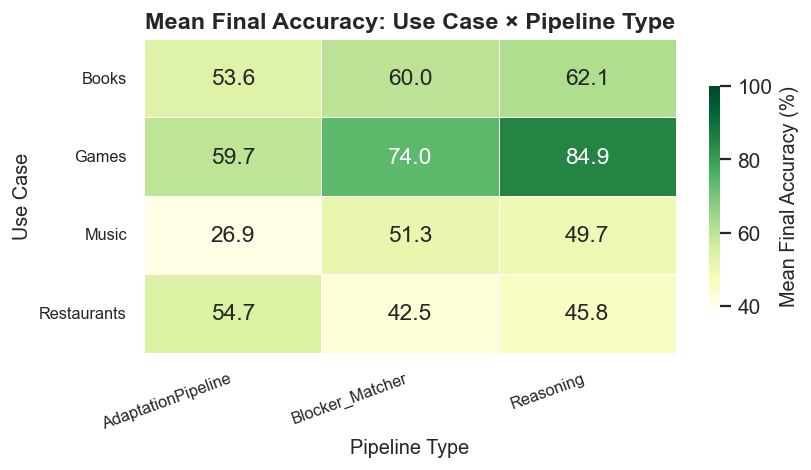

In [51]:
# ── 11e: Use case × pipeline type accuracy heatmap ───────────────────────────
if not all_eval.empty and len(use_cases) > 1 and len(pipeline_types) > 1:
    final_acc_uc2 = (
        all_eval.sort_values("eval_iteration")
                .groupby("run_id").last().reset_index()
                [["run_id", "use_case", "pipeline_type", "accuracy_pct"]]
                .dropna(subset=["accuracy_pct"])
    )
    piv_uc = (
        final_acc_uc2
        .groupby(["use_case", "pipeline_type"])["accuracy_pct"]
        .mean().reset_index()
        .pivot(index="use_case", columns="pipeline_type", values="accuracy_pct")
    )
    fig, ax = plt.subplots(figsize=(max(6, len(pipeline_types) * 1.5 + 2),
                                    max(3, len(use_cases) * 0.7 + 1)))
    sns.heatmap(piv_uc, annot=True, fmt=".1f", cmap="YlGn",
                vmin=40, vmax=100, linewidths=0.5, linecolor="white",
                ax=ax, cbar_kws={"label": "Mean Final Accuracy (%)", "shrink": 0.7})
    ax.set_title("Mean Final Accuracy: Use Case × Pipeline Type",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Pipeline Type")
    ax.set_ylabel("Use Case")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()
elif len(use_cases) <= 1 or len(pipeline_types) <= 1:
    print("Use case × pipeline type heatmap needs ≥ 2 use cases and ≥ 2 pipeline types.")